# Python Exercise 2
Assume an initial margin of 50% and maintenance margin of 35% for shorts and 0% transaction costs for all exercises. Any external dataset would be be close data with range 10/24/2022 to 10/24/2023 inclusive. All code cells are for you to complete. Keep a bankroll and keep track of how much is in your margin. Use an approprioately sized bankroll for the problem - for example, if only long one unit of something, a reasonable bankroll should be related to the price of that something.

## Returns Calculations

Given prices or an asset, use the signal provided and calculate returns of:

In [ ]:
#imports
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
import quantstats as qs
import numpy as np


#### Short
Use SPY data. Short 1 share when SPY has gone up the last day. Keep margin in mind.

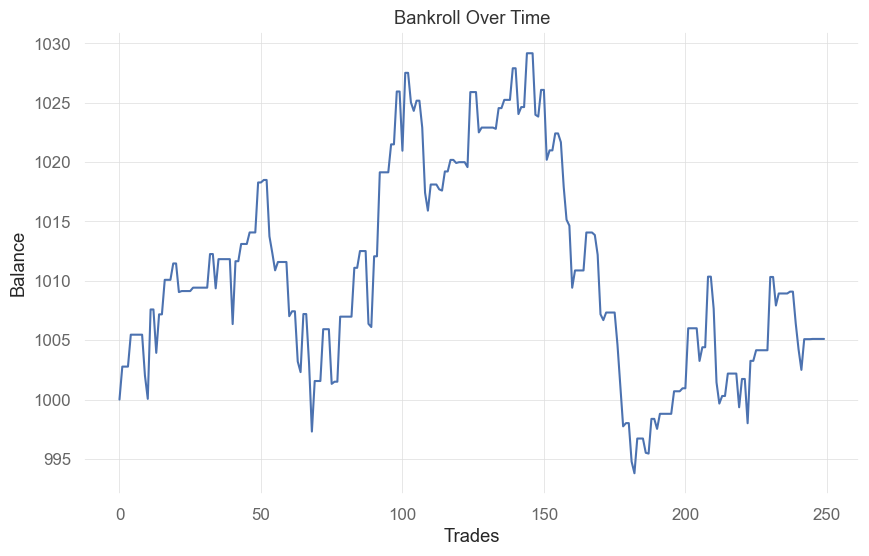

In [81]:
#Use yfinance for SPY data.
spy = yf.Ticker("SPY")
spy_data = spy.history(start = '2022-10-24', end='2023-10-24', auto_adjust = True)
spy_closes = spy_data['Close']
spy_returns = spy_closes.pct_change().dropna()
bankroll = 1000
margin = 0
margin_call = 0.35
portfolio = [1000]
for i in range(1, len(spy_returns)):
    current_price = spy_closes.iloc[i]
    prev_return = spy_returns.iloc[i-1]
    if prev_return > 0:
        entry_price = current_price
        exit_price = spy_closes.iloc[i+1]
        required_collateral = entry_price * 0.5
        sale_proceeds = entry_price
        margin = sale_proceeds + required_collateral
        equity = margin - exit_price
        margin_ratio = equity / exit_price

        if margin_ratio < margin_call:
            realized_pl = equity - required_collateral
            print("Margin Call")
        else:
            realized_pl = (entry_price - exit_price)

        bankroll += realized_pl
    portfolio.append(bankroll)
plt.plot(portfolio)
plt.title("Bankroll Over Time")
plt.ylabel("Balance")
plt.xlabel("Trades")
plt.show()

#### Long front month futures
Use WTI futures data. Long the front month futures and exit the day before expiry every month.

/var/folders/fp/93xv79yn301btyrjs9x_966h0000gn/T/ipykernel_45659/1768224471.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  wti_price = wti_closes[i]


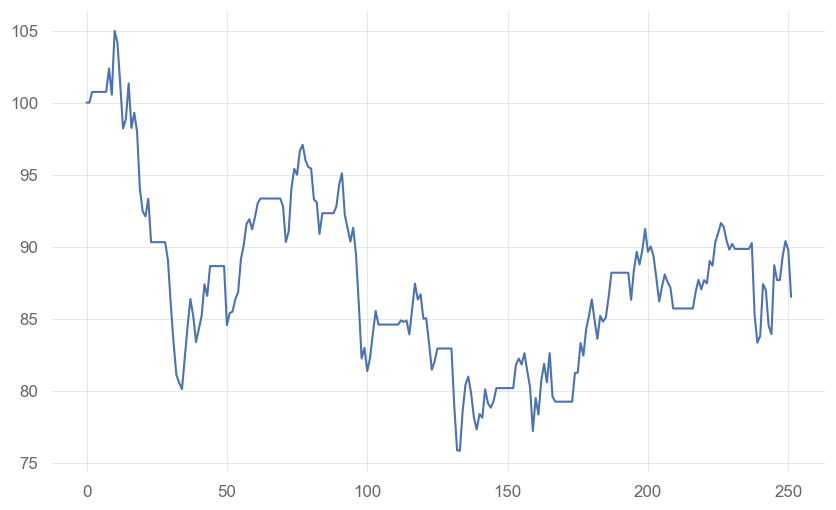

In [82]:
wti = yf.Ticker("CL=F")
wti_data = wti.history(start = '2022-10-24', end='2023-10-24', auto_adjust = True)
wti_closes = wti_data['Close']
bankroll = 100
portfolio = [100]
long = False
current_month = 0
for i in range(len(wti_closes)):
    wti_price = wti_closes[i]
    today = wti_closes.index[i]
    if today.month != current_month and long == False:
        bankroll -= wti_price
        long = True
        current_month = today.month
    elif wti_closes.index[i].day >= 23 and long == True:
        bankroll += wti_price
        long = False
    if long == True:
        value = bankroll + wti_price
    else:
        value = bankroll
    portfolio.append(value)

plt.plot(portfolio)


#### Pairs trade
Commodity A is necessary for the production of commodity B, and is required in the manufacturing process with a certain ratio. Determine when the spread is most worth entering and long A one unit of volume and short B for however many units are required, fractions values allowed.

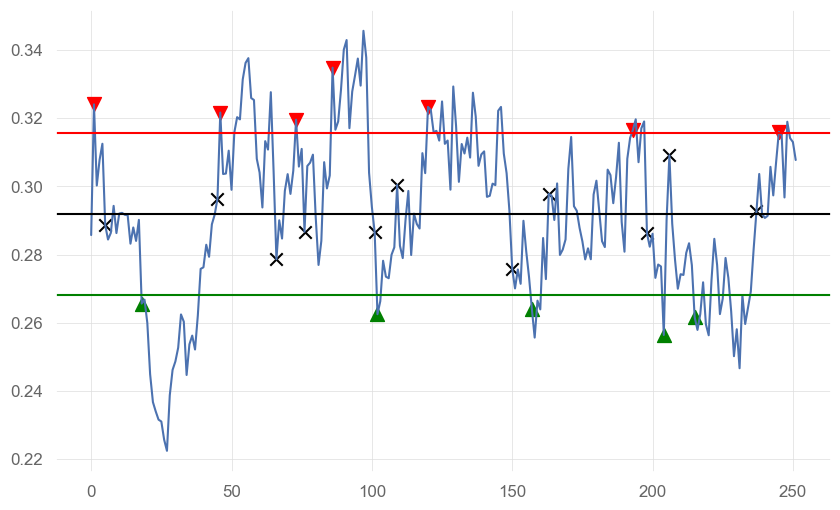

In [83]:
Aprices = [52, 52.301111211844024, 48.29449163943828, 48.864047698727504, 48.7012502537786, 46.559835552642205, 46.47209822411211, 46.1759582806993, 47.95540595728723, 46.973204010992276, 47.55792726381623, 48.06933797986882, 48.52209876104313, 49.33841836353801, 50.126998078631445, 51.09873155158019, 53.03089429965669, 54.8351243050858, 52.70159426086113, 53.69132538152354, 52.91101200579669, 49.74926915125003, 49.81268358018073, 48.4417008165448, 45.9603747653972, 47.62358888704854, 47.23628464298505, 46.78301110783908, 48.11834526753616, 49.943409828191065, 50.40869697560866, 49.673136084531464, 49.77602274466527, 51.578609571185964, 50.949437900224034, 51.31083655960703, 52.31757034910995, 48.85324469603913, 48.54176059973473, 48.99277937251458, 49.63250854917204, 50.28601479615026, 51.68775848422736, 53.06654872697125, 54.43494917545255, 53.93741893984055, 57.03426061544788, 56.554034103222584, 56.82882171815844, 57.7598325792229, 57.539002433758085, 56.86286626027488, 56.80024425893631, 59.67524700475677, 60.87557367188692, 59.87324424230547, 61.10771839712163, 62.93638954143433, 60.761063566658414, 59.09035631658956, 61.116331748749545, 59.27306783522045, 61.21477091954082, 61.26746425046163, 63.37850053917421, 63.83040653642044, 61.320472082046464, 63.18381920729989, 62.30301378736449, 64.75316148066833, 66.74242270750233, 65.83116201929202, 65.32521816826241, 66.69332055673071, 66.48867307618384, 65.81496305131485, 64.11075907403918, 64.93108976289881, 66.72094591352393, 70.68913913137294, 69.23250548679974, 72.08512098145202, 72.9057253125782, 77.63521552865535, 76.33426770900526, 75.03184196423467, 81.23220915078527, 79.89733136596149, 81.60298228874963, 83.65003736405365, 86.89655967437207, 86.0431713374494, 83.92133471106713, 84.0761234857481, 88.38727592170002, 90.14282446999115, 90.43941484436972, 97.74337530928531, 95.99370479317109, 90.58173137754301, 90.00761306452587, 90.50156046352495, 88.51816977923883, 86.83764355985417, 86.29214502788484, 84.87906775337355, 82.8307348391644, 82.80967087149584, 83.20660576513214, 89.01894878544178, 85.79386063167425, 87.61712871757551, 86.97740072763172, 87.67695365157809, 85.86492365791572, 85.57387147760181, 86.40499396545914, 87.3747934172034, 90.22555077954425, 85.92764784127897, 89.28390400563154, 89.41349724901805, 90.21789804659684, 88.70050976551347, 90.9160062762742, 91.58842932197533, 90.05738506670883, 95.5282857025636, 96.26339890249209, 100.75352194452418, 100.00378603814612, 98.50926241612997, 99.4440634749924, 102.4611151186134, 103.3794324314032, 106.69344951215379, 104.80582418972125, 102.01146485165704, 101.43362474601211, 104.02823140094009, 105.1009927286714, 102.53172469222861, 102.18922233601403, 106.03392085231492, 103.33260695915487, 108.71055443856191, 109.9194206224814, 113.36518229256134, 112.95321573539935, 114.18915963944403, 105.3368751347671, 102.81021140043651, 104.94707176625654, 103.34296079397355, 108.38446621150521, 108.21125510167055, 108.51967687124201, 104.99384117887188, 101.5911971985427, 102.89747269219657, 99.4334582795163, 106.8971675587677, 105.36777731049833, 109.57695614168733, 111.87927105476213, 109.01218104529237, 111.443244874029, 107.58278735970097, 107.06365862278648, 110.14170379667209, 114.53563109496642, 118.27949327235571, 114.70379832758972, 115.42542645846255, 115.91723258608621, 111.30184121805117, 109.33972500397472, 109.79211360742032, 108.07129528399943, 108.8733095474273, 111.73282742785298, 110.61932770138355, 105.89727464111976, 106.25129044428756, 106.4481824536428, 107.62446862732247, 107.54184346148361, 106.64202842257617, 106.8260899545289, 105.79443230672243, 104.81633037725508, 109.65019219324678, 110.24219136694079, 113.15947887699888, 117.45125917993211, 111.52524588629292, 115.58307771082802, 116.1422542565686, 114.05836399265853, 112.36257161861661, 115.50639099038472, 111.7945278385582, 115.27258619218384, 116.4609128567086, 116.1232112361531, 116.76150332894632, 119.09740931369369, 116.50430385880264, 117.4917511561877, 110.48955185132428, 107.29163121451712, 110.53792630686377, 110.8654915363711, 110.51167499656079, 111.85106342831216, 110.82492964334594, 110.52554759677416, 114.28663527330465, 122.00496318957192, 121.89485912150651, 123.31874128406936, 130.44308083809457, 129.06585973201655, 121.66009702203397, 123.01993094426409, 121.76841838346978, 122.83367398434265, 121.81746471069177, 118.23752199554777, 118.52590443200596, 119.66790221409393, 120.02726177854649, 121.26630081147533, 120.81915827702258, 122.27652293197606, 123.59386112962142, 126.12151509848043, 127.54643793536883, 127.19751634886391, 125.26362098808707, 128.04188527847484, 124.4055312557812, 126.70968853443824, 127.62254232802736, 135.40952488564534, 139.80125903176443, 139.61822250779952, 138.07776626566584, 140.75990249982877, 139.68855501421478, 144.17192071494608, 142.0312240280674]
Bprices = [182.0, 161.38640986321607, 160.84885479667028, 158.75694511467853, 155.8384845825986, 161.2953530289703, 163.40636454070025, 161.2609562448676, 162.96039288014057, 164.0751590031314, 162.8534505365793, 164.49322309580907, 166.3723655766957, 169.22576889254074, 177.01398035013625, 177.4604569879708, 186.73348223108647, 188.9765802880872, 198.42687991236028, 201.28092167707612, 203.5453596062136, 203.17093001376583, 210.47599428864024, 207.07661228668658, 198.5132986193077, 206.19160772520718, 209.35254540588656, 210.38015326351183, 201.61857479915412, 202.91946991764152, 202.76525675027344, 196.6077323074555, 189.68999281938554, 198.16720025747563, 208.27041898593512, 202.29744823775312, 204.21280153905477, 193.77499457703763, 185.18130170233488, 177.6533015570704, 179.6703523123176, 177.77115598229327, 185.03862217346804, 183.71146553342564, 186.619720709369, 181.96472809546503, 177.30558937600372, 186.26084097720033, 187.08382391960802, 186.03445050632936, 192.44508766837455, 180.03980589040026, 177.32557182278148, 186.67889819779995, 183.6903392743917, 178.0666695555516, 180.98368459382118, 193.09894718497668, 186.75031314695713, 191.78801055569755, 201.0129899057301, 201.74270669983034, 195.4007649562177, 197.1319247021172, 193.43216260835342, 209.81624052872576, 220.09857313003474, 217.83984274044283, 218.85016063088545, 216.79272052430147, 219.84357292166723, 221.0662224499288, 214.48455441401717, 208.69284760739026, 217.41638002505226, 211.62246918039054, 223.61586236619175, 212.20838613324992, 217.35742316200748, 228.536971256779, 238.04671604269396, 260.2973126749541, 256.69396353940596, 252.79444521531497, 254.9598674545123, 247.4712483544639, 242.5913284131692, 252.34261642069734, 255.7635641966164, 254.74070412108827, 255.48062373459416, 250.89307043026773, 264.66835149461156, 256.4610723895453, 265.79336549515205, 267.0737462912244, 274.4077171250734, 282.76679092359296, 284.15869624916576, 297.953547414528, 306.1862435541235, 315.9037348270169, 337.2385090577499, 326.0891827628519, 310.21791458220525, 310.35652906592225, 303.36815608073823, 295.84314561295656, 294.9448404679091, 296.3167290036442, 303.6248595975891, 314.09708294820933, 299.66660978922937, 293.5669147162902, 306.825150085099, 293.0697126985071, 299.0061943399092, 303.7800909166435, 291.2828615307778, 282.76634130129605, 276.138703538348, 277.31427197046224, 285.60120226541073, 280.43219453504685, 290.06448185837024, 281.8711899993692, 288.1991352394559, 304.7534930246558, 321.91947146176375, 305.9418494956109, 314.75723266130234, 326.9191641120969, 318.2776477036815, 330.89784208517347, 328.9231211056882, 345.900465113657, 320.01889916275184, 318.2978809308224, 331.4461403874435, 336.2416938173959, 338.7335979184753, 345.31352506852375, 343.80283838393837, 352.5067071690148, 344.01128487229124, 337.406642380602, 339.965166672035, 366.133297405074, 371.72448287004954, 389.89855705515646, 381.91838912851557, 380.71336991567387, 380.7719322178305, 380.77573649387665, 373.86928647156844, 385.2707490860059, 397.0702857222959, 397.6546528843797, 397.44523237011396, 386.17068017134466, 376.8076316167108, 375.2835712563147, 386.2750375127616, 367.9960966834495, 376.2887352090136, 375.7379312231546, 370.4071180940755, 384.40778514224536, 380.4044960347581, 387.2565187721624, 375.3097771480265, 376.0837504507039, 389.9273639884599, 394.1549111571108, 402.7778535762669, 392.0986596451207, 392.512306116814, 389.5921985627425, 387.89218365890514, 365.81639917663676, 370.38804716346436, 377.60329629541593, 372.997813724349, 376.53829699727373, 349.1068747180083, 354.8369093494995, 364.46779915409195, 352.2381157086801, 341.5122337488584, 365.3583280978516, 373.2501194270685, 355.88071324928416, 350.84101506728774, 357.45747104519563, 367.39453672830683, 363.1603390949638, 364.5988424692484, 364.0155301339608, 398.42588004311267, 398.0481258651905, 403.7267797271378, 409.2895154113221, 416.0688589218046, 421.2245626410239, 452.9267751582314, 402.3456037086529, 385.29246328320096, 403.03182355930113, 421.93587774956313, 409.29403324478426, 391.26589315357415, 403.43434562006024, 395.2708164242953, 390.074899275671, 404.0193721450585, 423.6431398045914, 428.6285198557819, 435.3306019409638, 448.81322687123577, 469.7078739543236, 481.1613011587025, 478.6407041814145, 453.49171412567154, 439.36746799655657, 468.63444787146585, 455.9463430539092, 440.28254275773895, 445.96885230392667, 448.9638762471827, 473.82494698716835, 463.72206250365974, 486.7086094978438, 452.3414565848496, 465.412695486046, 462.5036807437907, 459.2101663126207, 448.0835882366627, 435.8526137850277, 418.90678835828675, 429.0422897302155, 440.4148709981327, 427.00824236180097, 414.4390391470074, 429.19800288796176, 441.08825894349116, 442.36718794991646, 443.3674088064908, 465.3073928664386, 441.29595063674356, 444.65780944003285, 460.5983254303148, 461.5240530856465]

ratio_series = []
for i in range(len(Aprices)):
    ratio = Aprices[i] / Bprices[i]
    ratio_series.append(ratio)
mean = np.mean(ratio_series)
upper_bound = np.std(ratio_series) + mean
lower_bound = mean - np.std(ratio_series)
exit_signals = []
buy_signals = []
short_signals = []
state = 0

for i in range(1, len(ratio_series)):
    if ratio_series[i - 1] > lower_bound and ratio_series[i] < lower_bound and state == 0:
        buy_signals.append(i)
        state = 1
    elif ratio_series[i - 1] < upper_bound and ratio_series[i] > upper_bound and state == 0:
        short_signals.append(i)
        state = -1
    elif (((ratio_series[i - 1] > mean and ratio_series[i] < mean) or (ratio_series[i - 1] < mean and ratio_series[i] > mean)) and state != 0):
        exit_signals.append(i)
        state = 0
plt.plot(ratio_series)
plt.axhline(mean, color='black')
plt.axhline(upper_bound, color='red')
plt.axhline(lower_bound, color='green')
plt.scatter(buy_signals, [ratio_series[i] for i in buy_signals], marker='^', color='green', s=100, label='Buy Signal')
plt.scatter(short_signals, [ratio_series[i] for i in short_signals], marker='v', color='red', s=100, label='Short Signal')
plt.scatter(exit_signals, [ratio_series[i] for i in exit_signals], marker='x', color='black', s=80, label='Exit Signal')

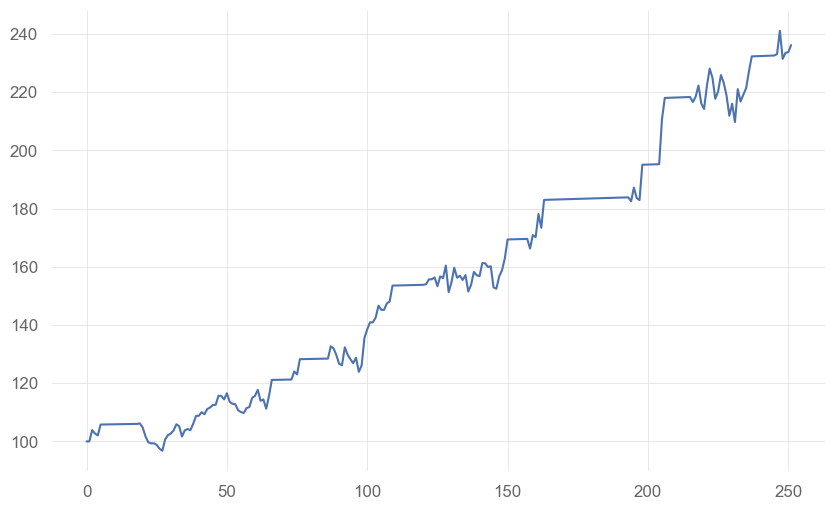

In [84]:
portfolio = [100]
a_shares = 0
b_shares = 0
a_shorts = 0
b_shorts = 0
bankroll = 100
rfr = 1 + (0.04 / 252)

for i in range(1, len(Aprices)):
    bankroll *= rfr
    if i in exit_signals:
        bankroll += (a_shares * Aprices[i]) + (b_shares * Bprices[i])
        bankroll -= (a_shorts * Aprices[i]) + (b_shorts * Bprices[i])
        a_shares = b_shares = a_shorts = b_shorts = 0
    elif i in buy_signals:
        a_shares += 1
        bankroll -= Aprices[i]
        b_shorts += mean
        bankroll += mean * Bprices[i]
    elif i in short_signals:
        b_shares += mean
        bankroll -= mean * Bprices[i]
        a_shorts += 1
        bankroll += Aprices[i]

    value = bankroll + (a_shares * Aprices[i]) + (b_shares * Bprices[i]) - (a_shorts * Aprices[i]) - (b_shorts * Bprices[i])
    portfolio.append(value)

plt.plot(portfolio)
plt.show()

#### ETF Arbitrage
An ETF is composed of a basket of stocks A, B, and C. The ETF contains 9 shares of A, 6 of B, and 5 of C. The ETF is never worth less than the sum of its parts, but it's sometimes worth more. Determine how much of an offset it's best to enter a position to trade at and trade 1 unit of the ETF as the notional.

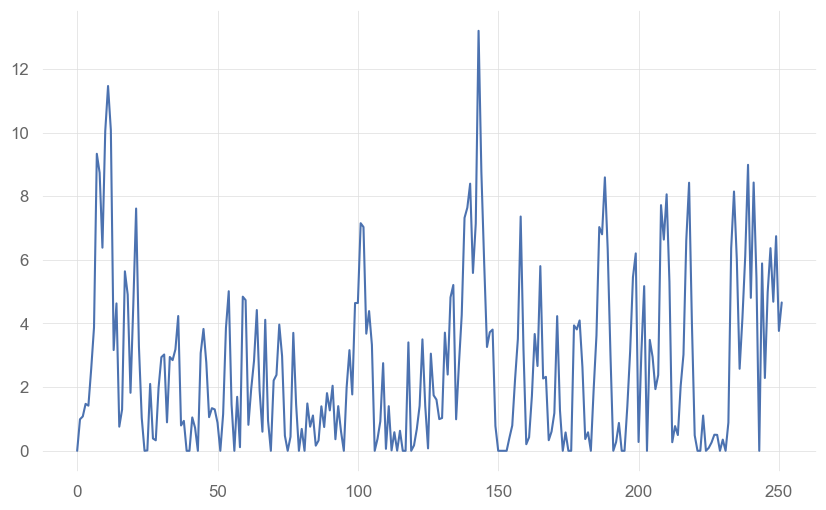

In [85]:
ETFprices = [249, 248.54005306639084, 244.71469471066416, 247.5955317445332, 245.25029811915826, 246.18610009923154, 248.24483467061737, 254.7043712211926, 258.456316444099, 255.07898956904407, 258.5666519210814, 258.0390694884022, 260.71073039622786, 257.9697852235324, 259.88724446281094, 255.03003221042215, 255.81668347105895, 258.28680733880674, 255.6620694377799, 254.1464112574216, 257.65574704606894, 259.8570018149645, 257.0394941376629, 254.98072932156222, 253.83707573605, 255.97931680793874, 257.46096453033346, 250.96872180175322, 246.3351629890675, 245.77597394264424, 248.94978443679423, 250.54613853729995, 251.08463079918025, 252.35927352221896, 252.25402453060278, 253.23109265611114, 258.8342691659338, 255.21384627305014, 253.03697244451627, 251.53435831407464, 250.68314435758617, 247.40279974768953, 243.96954367717106, 243.83291008563864, 246.187556823177, 245.03549846741055, 243.61969167166725, 241.85423798329106, 241.59609383721656, 240.03429009655406, 234.806062217711, 234.0464117902289, 235.72953553197715, 237.5723292469908, 238.70748498906283, 235.63958180794577, 236.4955366714048, 237.06883089713568, 237.09489991685902, 241.91501131626273, 242.66724826416842, 241.2208902928548, 243.02580743874796, 243.44566720504164, 244.34655183937176, 243.86045536050247, 245.18476890788696, 248.43711447539658, 246.21862690835232, 244.31117738719698, 246.26886608495977, 247.82482417023502, 248.55030312274727, 245.02948077980932, 242.7943737273084, 242.2783390701902, 240.7855981960528, 243.62265750159935, 241.04911614336942, 241.73732016141136, 246.76651951481324, 244.4667229099821, 242.96032087235997, 244.8074215309401, 241.90526718015255, 239.41579821639078, 237.74057920158964, 238.2729047370459, 233.50808475104262, 237.64347169384502, 240.01916468628377, 242.26073507146228, 241.98924252718442, 243.45924634961807, 242.52817909248117, 241.24938712570875, 245.90602909747608, 246.34690744597344, 248.4405530232436, 250.31782098348955, 247.4721351966448, 248.92742711118726, 252.33936613510113, 251.46548671767042, 253.9414472661511, 252.75684208831376, 252.42897070916672, 250.31965611808351, 249.16000493934752, 250.74999500443596, 251.1544529752174, 252.32803900796765, 248.59889355395188, 246.4914915870157, 241.49240475625461, 241.89526486802728, 239.98698678990849, 238.88512287037668, 241.9010210391958, 239.4835934661179, 237.72267983852012, 238.33524948679676, 240.61188082422393, 244.62039907697522, 242.65897925893333, 239.82066405817972, 243.02455951318126, 243.98944666126604, 244.93782647305065, 244.04978316202562, 244.53073634382457, 246.37252620128257, 245.1677256359472, 248.51574715618645, 250.7673590948435, 245.09742611681358, 245.4042021417498, 247.04438604849653, 252.26832887747005, 254.23202535322747, 255.46645170382783, 258.1292155081655, 261.9380427004985, 268.7258935671203, 265.79656944594853, 262.3098343969125, 260.25254700511124, 262.530858125313, 262.28929834316045, 258.47683130897263, 256.05415912976025, 256.92858070837326, 255.42506618065704, 256.09298516636665, 256.57340487771376, 259.7810052262129, 260.398742833673, 260.75207338340016, 262.6674959680425, 260.9367118378028, 257.66088614055633, 257.9525494183955, 257.2994321143463, 260.48354597667554, 258.8076834428887, 261.8822259278411, 260.32311505114336, 261.34174678220376, 260.37988745734634, 258.71054228695914, 255.95013437882704, 259.3929302027787, 257.9726637811534, 255.97238743662157, 253.8569815359171, 251.26016805458903, 252.3310057969376, 256.9277860819504, 258.51605651163715, 262.3624166535342, 260.16837244718374, 259.39907732712373, 255.71269955698696, 254.5856803268764, 255.29520212352048, 257.88998607484854, 260.64390949489336, 261.8521517323502, 262.5838999180632, 263.56052354039696, 262.94790416584345, 261.509292472357, 260.90200039087927, 259.97395354743725, 260.8767046589396, 263.9464563311519, 265.9889496166522, 265.0781117387143, 269.4226811064912, 270.24006944094384, 263.9286512379536, 266.35634307478057, 269.89256435386517, 263.3888093050299, 265.4172751820158, 267.7434186147926, 266.83493654426, 267.77374900963906, 274.895095701608, 275.74379013504563, 278.06246457996167, 278.02030129105367, 274.3236836375328, 272.618364798674, 271.04889380255196, 273.9995007467641, 277.1539457914889, 283.5815386735756, 285.9780057133252, 286.20394923229054, 285.1657646072547, 279.5535173187865, 276.6348362620125, 274.37180334368287, 273.71940836263093, 273.65988421268133, 274.5609017246471, 274.93730411258304, 272.2325781623388, 268.8020611935712, 271.42437872909517, 273.68175497780055, 276.3230132537982, 280.0058106497564, 283.10163816964706, 283.2668743466842, 283.7140230530654, 282.90903238318083, 288.61797129012575, 292.4882062391846, 292.81141308485775, 296.18056573907796, 297.93503908485724, 297.5401733022711, 300.9257663848733, 294.98117746106675, 298.0205803008596, 299.887243011656, 297.8981681583563, 301.23743415146436, 302.0815202740542, 303.7206744670804]
Aprices = [15, 14.948894785154538, 14.539076694915467, 14.63296418340467, 14.366228198514923, 14.363154858873202, 14.501414525726048, 14.648839642165886, 14.959719484909, 14.739093953424135, 14.66735724156149, 14.569919301468468, 14.827561495471995, 15.22257036973104, 15.071347875982113, 14.916879110198986, 14.855938389789323, 14.767730566323296, 14.61877911925444, 14.71326104186585, 14.812422599298573, 14.661961765628394, 14.72827044459864, 14.722091782865828, 14.710108741701411, 14.948135527466825, 14.936245586222354, 14.448382388232517, 13.976562315457004, 13.860168819569557, 14.025822530002518, 14.162946857082773, 14.373499388157121, 14.338304883653315, 14.40661518956185, 14.38314855541498, 14.668670531972296, 14.736957662854032, 14.583601199463784, 14.43778408292716, 14.343204754428447, 13.978722019995484, 13.713829159415106, 13.779198176977541, 13.55962902169458, 13.448672853202488, 13.394190109250612, 13.371843108625608, 13.399223259188208, 13.374516636924103, 12.938051312495027, 12.951765527875288, 13.138779276958429, 13.023441205717837, 12.98425763938546, 13.001769363515168, 13.039768647779782, 13.005795608273608, 13.163183991535567, 13.10822024880286, 13.28141517391987, 13.441025369688195, 13.525428483761948, 13.443287591293679, 13.322559394138393, 13.545756094263577, 13.902744516100254, 13.851523062720732, 13.81202322888749, 13.7051274984788, 13.614123552343132, 13.714806035143404, 13.654666555996798, 13.491109475762602, 13.573689469521616, 13.517300569111145, 13.351440471984766, 13.480476613651966, 13.457544318681212, 13.558976943820582, 13.770904137726726, 13.591774485096607, 13.42439648091637, 13.51406384635371, 13.275718235064558, 13.122293044611412, 12.954179946258552, 13.019340640280202, 12.645252775779397, 12.84013138957002, 12.906709032281984, 13.08956864975558, 13.126022798242083, 13.271058498267044, 13.323524398665597, 13.248731986775839, 13.456946936424007, 13.370706122781996, 13.491456416465633, 13.33620206451788, 13.121172124328467, 12.950737401007354, 13.079273954674521, 13.222805245277597, 13.35645054404222, 13.311848382473778, 13.545451544283617, 13.311083256385485, 13.224107671854869, 13.102601213026526, 13.047678646773083, 12.963665107147046, 12.705054955903709, 12.472411869689688, 11.981800004932094, 11.839493475888307, 11.697317142118939, 11.574887817726514, 11.626014143157082, 11.585326471353584, 11.389669401620498, 11.476602645363759, 11.539296529142108, 11.584612536692939, 11.578328693641813, 11.419995814080304, 11.329994687345478, 11.446538079671718, 11.457232556191588, 11.537080430407096, 11.504660080333817, 11.247144111960138, 11.247297195541385, 11.31921484615949, 11.436388249903246, 11.385221071589765, 11.406087776183046, 11.32570920059067, 11.435619112507409, 11.574211586177192, 11.671511179348132, 12.04585810399596, 12.203617654441562, 12.224185969245458, 12.249096579833255, 12.23574986168981, 12.250853781181412, 12.311565884829697, 12.372435751255443, 12.372038725059051, 12.189699443230605, 12.286857396409829, 12.119800226663582, 12.158890221051038, 12.00185082370297, 12.31445401008448, 12.342727648598428, 12.232375490426698, 12.046630689778034, 12.071398474603305, 12.049422442638125, 12.104790774846581, 12.037617061889716, 11.947146845806387, 11.908868504374897, 11.88763325809828, 11.838235640282418, 11.792362366238851, 11.842017223912212, 11.693507371288126, 11.346495213096384, 11.236993799208586, 11.320364330832806, 11.239557121916938, 11.00451202183866, 10.780033730089592, 10.899015701461657, 10.80080445450334, 10.77312470218594, 10.864285826835967, 10.789089922730106, 10.94354710238881, 10.574973567112938, 10.513983414146471, 10.410736440996162, 10.377576211138559, 10.195960165560779, 10.10307067685746, 9.988371101420206, 10.221230015754694, 10.367330376359332, 10.53973960380096, 10.47226270585899, 10.3997298977532, 10.49047642960785, 10.608749632062754, 10.762834474573024, 10.597331094053212, 10.568498231499607, 10.620893838617738, 10.487132990654734, 10.375050749421614, 10.406509397086117, 10.258695629886912, 10.192991561677822, 10.245733013480852, 10.315681984624849, 10.428958300809803, 10.377429022557243, 10.391391710470964, 10.409117782624286, 10.592649076402266, 10.66916427172593, 10.509703932875595, 10.421533074590146, 10.317837382729302, 10.364894942477573, 10.470565578678487, 10.402653616457838, 10.38122695252682, 10.662778453673129, 10.093191452033018, 9.768893556835913, 9.517445454799283, 9.39083240914384, 9.374611030407127, 9.429117110654099, 9.431724352585517, 9.187302559662129, 8.86179398366759, 8.943741414712507, 8.960779893183426, 8.972977500353213, 9.044597260607636, 9.182723358006795, 9.11383272115316, 9.313150362341116, 9.106158770206994, 9.06256215513035, 9.071897542095325, 9.211728656008681, 9.003153227379073, 8.967066731974763, 9.026124193824824, 9.052367815641963, 9.036528602962134, 9.152551170720733, 9.05354757067543, 9.116163904684354, 9.274113041827901, 9.313235987344662, 9.201142263881973]
Bprices = [9, 8.926770558875907, 9.015200224813206, 9.187721485378837, 9.113694924353855, 9.021085751380125, 9.036762007179268, 9.085158342062376, 9.089389670719791, 9.234824685664826, 9.396606731990568, 9.376454630481906, 9.459088537507926, 9.562662900186568, 9.60248517273967, 9.668529149287114, 9.764399939299178, 9.677976984317546, 9.606314582512956, 9.64075453890361, 9.623029348478575, 9.722390972937852, 9.626703466363828, 9.66069876049926, 9.629193254138231, 9.629193254138237, 9.671890672534767, 9.667240345539053, 9.666711402144358, 9.640459539508393, 9.633510547915854, 9.776653054961693, 9.901493455694364, 9.952277974308565, 9.864224925923263, 9.99409010282796, 10.177722562698767, 10.177722562698763, 10.147817350926976, 10.27285646295882, 10.272856462958815, 10.272856462958819, 10.237655979464337, 10.237655979464341, 10.468420273483776, 10.422714312213536, 10.521493117096263, 10.476635655323658, 10.405640251867965, 10.23687207649399, 10.23687207649399, 10.209046119372852, 10.114204316545107, 10.093707939800503, 10.153487424573878, 10.25337880318752, 10.428145174397539, 10.406723035475492, 10.409045048217548, 10.514106600329136, 10.606202094752422, 10.683216275808533, 10.7306845516033, 10.77135168791332, 10.858548135615155, 10.943570396135122, 10.938503524876248, 10.955785061821182, 10.91985543735771, 10.919855437357706, 10.91548161818279, 11.024724476600587, 11.011346375693844, 10.940117488418874, 10.924773295828112, 10.982133874310056, 10.982133874310053, 10.669800767701602, 10.716873646666347, 10.859833720741351, 11.212857885404345, 11.212767595613329, 11.152058831279176, 11.357815223923568, 11.284825163670734, 11.243069920858932, 11.243069920858934, 11.129565109633207, 11.119031283936362, 11.289587738198328, 11.496408587481907, 11.46156616472457, 11.495576887301654, 11.390076844589037, 11.378765268582402, 11.378765268582404, 11.41480339105001, 11.501677061315995, 11.633155241901427, 11.682550576098553, 11.582208335375704, 11.649158304267978, 11.909300758906355, 11.997361731297312, 11.902830660926947, 11.93023788330365, 12.080045275269484, 12.080045275269484, 12.080045275269484, 12.189760189514375, 12.572517388075385, 12.498612697453138, 12.425429449773686, 12.26577414730046, 12.265774147300462, 12.35753602241831, 12.35753602241831, 12.35753602241831, 12.439974480929179, 12.494665000436893, 12.49466500043689, 12.42678438449111, 12.500386847588421, 12.455604299179168, 12.587034406928296, 12.587034406928296, 12.818424718629483, 13.02122388851251, 13.17714887071487, 13.156426688267464, 13.354013471418847, 13.557448100114526, 13.628372415673613, 13.694798994809146, 13.758088265984593, 13.687644744733822, 13.545762814760936, 13.611178807374852, 13.693066621479746, 13.622561541243943, 13.495321411001202, 13.782568396910362, 13.91273326655369, 13.934035879789706, 14.035539889535503, 14.070635846533595, 14.334090014341976, 14.385107637221617, 14.249245943768575, 14.249245943768576, 14.249245943768576, 14.249245943768576, 14.212759781811322, 14.265444621181741, 14.528596634275043, 14.508057171005524, 14.487585914547559, 14.46099908793168, 14.428606337200323, 14.727693332410531, 14.666330203054407, 14.66633020305441, 14.425210815829368, 14.645397642614641, 14.395440781775863, 14.37225896686987, 14.585107218283756, 14.695342618807146, 14.661980552261667, 14.624119781456185, 14.630784129508365, 14.963589626580276, 14.94137099166838, 14.941370991668386, 14.941370991668386, 14.941370991668387, 14.941370991668387, 15.04407551980508, 15.320560215786069, 15.400699370523089, 15.421512781992691, 15.50007991621588, 15.369450578569799, 15.370059179072223, 15.473731356314673, 15.571989541373874, 15.747284308068641, 15.980412555189199, 15.913608116694705, 16.06052523680684, 16.260244175433684, 16.26024417543368, 16.12172429650323, 16.121724296503235, 16.230317401978894, 16.42009238182524, 16.499302683008693, 16.503841934610715, 17.000356972189145, 17.113243493850945, 17.293206490520653, 17.500032053619936, 17.624054766607248, 17.53538006757113, 17.33167567920977, 17.59145967661088, 17.388712079105655, 17.114384163326097, 17.28872733998864, 17.416311901772083, 17.699222206101645, 17.968093586049683, 18.121396798748258, 18.121396798748254, 18.121396798748254, 18.372198331809784, 18.68131861704911, 18.807106043135022, 18.91623420889113, 19.52204113053335, 19.415381396641433, 19.35454416841436, 19.219716844567728, 19.140398322622758, 19.406309476324637, 19.420720852771442, 19.504354470591423, 19.51720434426308, 19.51720434426308, 19.51720434426308, 19.712732113031016, 20.02928330169169, 20.251094520924312, 20.15657852737848, 20.09824486533712, 20.447218615031275, 20.500014854227157, 20.46164569118669, 20.996543853606333, 21.215744123691614, 21.691025204432623, 21.913035923127595, 22.652038665280983, 23.4036211602585, 23.088716023645652, 22.74065683406282, 22.600525699588864, 22.677774200780696, 22.576273879865443, 22.62927085949265, 22.626659748922858, 22.781289233256096]
Cprices = [12, 11.889905623149955, 11.738398177938514, 11.859632527794844, 11.970736266496557, 12.04315262157882, 11.926716853715362, 11.804353590185942, 12.10952128866438, 12.127124296274253, 12.028026585860683, 11.837820622492144, 12.086818058013034, 12.084971254879639, 12.399863835557193, 12.401588681612589, 12.445942887972937, 12.334048775666206, 12.30934661344996, 12.411886261237125, 12.401072470324134, 12.39054584695314, 12.689111071673926, 12.696380899548346, 12.734187507181579, 12.731749964509874, 12.580387254490393, 12.50853201534403, 12.443152503408571, 12.24134035962672, 12.394848155707656, 12.278742827523063, 12.283826667595354, 12.130495200732748, 12.112069287373233, 12.126181406216222, 12.302978386234255, 12.143645254629925, 11.991432557995452, 11.991432557995452, 11.991432557995452, 11.78158849293644, 11.678838123210946, 11.678838123210946, 11.654159079677376, 11.526456314806817, 11.433512387505099, 11.518220371599904, 11.44595977060587, 11.388473589258366, 11.211857916077468, 11.245249064622834, 11.128535851532096, 11.188818254395322, 11.182894827963684, 11.128566845715458, 11.313749559000307, 11.175983357378264, 11.21161772038719, 11.202705140291009, 10.952412448878288, 11.067139059858881, 10.993770471628173, 11.000967461332078, 10.973826572219032, 10.87972917723479, 10.765765753227175, 10.78445476752656, 11.089179455348308, 11.089179455348306, 11.207860272028945, 11.171924349255937, 11.12504726483994, 10.998092714220125, 10.921490478376041, 10.945966140465917, 10.857899447499355, 10.914715328499604, 10.834562521319976, 10.909505068515603, 10.972721046337313, 10.972829394086535, 10.748250023135158, 10.855382344206028, 10.72124196657273, 10.738908032021815, 10.673780287521394, 10.584683822245758, 10.447870763848641, 10.506576193666756, 10.72211361745485, 10.728189948890899, 10.90356638866883, 10.855199687391314, 10.747641526646355, 10.747641526646357, 10.862441641576947, 10.767522891035846, 11.089549859216866, 11.11069068906045, 11.048782336358961, 11.064951318156773, 11.227713971354872, 11.359156277173195, 11.58532438940519, 11.607927031799449, 11.607927031799449, 11.53255284820736, 11.3473879348095, 11.386766142659807, 11.645685922234724, 11.852344553219938, 11.937441612233275, 12.0123119656126, 12.011147920311256, 12.113183275265635, 12.113183275265635, 12.113183275265635, 11.844184466272, 12.049533044262859, 12.015567135180317, 11.95977606711545, 12.06883761621273, 12.424871978970467, 12.30369905797744, 12.288494173330678, 12.218302872888923, 12.220114755807629, 12.230633212814507, 12.05641919173506, 11.966902724826916, 12.018170546248951, 11.955197381860408, 11.930557968683248, 12.016381375319629, 11.902845815714398, 11.752297126255119, 11.835806029544933, 11.97392282192275, 12.13769525251605, 12.211559135244814, 12.286694185190933, 12.298178510593749, 12.38157981617215, 12.51677675493883, 12.37278319352543, 12.145554792103527, 12.338051429328651, 12.326601424165942, 12.170277695614669, 12.170277695614669, 12.170277695614669, 12.214061089963375, 12.214061089963375, 12.194757252719725, 12.221687529752415, 12.029416120775469, 12.076129042367198, 12.063017789837692, 12.147745066024518, 12.202290245289966, 12.117431940722437, 12.137297368893456, 12.283408466841243, 12.51818063455835, 12.571562029608202, 12.799187651034224, 12.9430294163077, 13.099418526359202, 13.02407129452048, 12.972152932140238, 12.84945846531551, 13.033629477871765, 13.033629477871765, 12.918327706754475, 12.918327706754473, 12.918327706754473, 13.103350604570904, 13.16406374711569, 13.61673318218912, 13.581334781665836, 13.507491591135047, 13.547894905024963, 13.547894905024965, 13.366900184237199, 13.487247958284645, 13.473299908416674, 13.6479122212005, 13.723184446615287, 13.771959984240375, 13.818034197109254, 13.818034197109256, 13.929207737727811, 13.754146277436856, 13.816102476119118, 13.98943107032714, 13.745874702090541, 13.511760501806359, 13.369586023407885, 13.15398712633046, 13.101569361984055, 12.97866585347373, 13.063244007280838, 13.16965364612418, 13.241146653660845, 13.406888889406112, 13.54464746735998, 13.769307278154937, 14.009456048630664, 14.217412844106333, 14.02528196097809, 13.914564879901977, 13.860529722060825, 13.705343067750222, 13.60643899682935, 13.773931248586159, 13.751055501010285, 13.977876989227035, 14.086693576445306, 14.322737704613576, 14.444501174128147, 14.517505848000633, 14.67929863661659, 14.552811964477707, 14.552811964477707, 14.534544181042337, 14.482348358528016, 14.488725811960235, 14.388537854996878, 14.388537854996878, 14.460440330014313, 14.57180722579991, 14.634691062585063, 14.260062795103568, 14.344156203061065, 14.508877794174428, 14.86358317700463, 14.803612451178621, 14.992009265698004, 14.912197402776274, 14.99064878049911, 15.049015004757363, 15.17666571925934, 15.176665719259342, 15.006962645795808, 14.98403270897945, 15.011562530652844, 15.19431410743233, 15.142182578262167, 15.050357889987197, 15.747218117435745, 15.912474545819197]

etf_adjusted = []

for i in range(len(Aprices)):
    a_adjusted = 9 * Aprices[i]
    b_adjusted = 6 * Bprices[i]
    c_adjusted = 5 * Cprices[i]
    total = a_adjusted + b_adjusted + c_adjusted
    etf_adjusted.append(ETFprices[i] - total)
plt.plot(etf_adjusted)


In [86]:
def backtest(deviation):
    bankroll = 100
    etf_shorts = 0
    a_shares = 0
    b_shares = 0
    c_shares = 0
    state = 0
    port = []
    for i in range(len(etf_adjusted)):
        a_price = Aprices[i]
        b_price = Bprices[i]
        c_price = Cprices[i]
        etf_price = ETFprices[i]
        if abs(etf_adjusted[i]) <= 0.01 and state == 1:
            bankroll -= etf_price
            bankroll += a_shares * a_price + b_shares * b_price + c_shares * c_price
            a_shares, b_shares, c_shares, state, etf_shorts = 0, 0, 0, 0, 0
        elif etf_adjusted[i] >= deviation and state == 0:
            etf_shorts += 1
            bankroll += etf_price
            a_shares += 9
            b_shares += 6
            c_shares += 5
            bankroll -= 9 * a_price + 6 * b_price + 5 * c_price
            state = 1
        value = bankroll + a_shares * a_price + b_shares * b_price + c_shares * c_price - etf_price * etf_shorts
        port.append(value)
    return port

best = 0
for i in range(1, 13):
    test = backtest(i)
    returns = (test[-1] - test[0]) / test[0]
    best = max(returns, best)
    print(f'Deviation: {i}')
    print(f'Returns: {returns}')
print(best)

Deviation: 1
Returns: 0.4879598589147855
Deviation: 2
Returns: 0.6122357075411997
Deviation: 3
Returns: 0.6168584035747773
Deviation: 4
Returns: 0.7214177370205579
Deviation: 5
Returns: 0.6186395800922599
Deviation: 6
Returns: 0.6018676080139101
Deviation: 7
Returns: 0.5405954690830254
Deviation: 8
Returns: 0.4252175169299636
Deviation: 9
Returns: 0.22528201922707836
Deviation: 10
Returns: 0.2323676891009339
Deviation: 11
Returns: 0.24658070364146029
Deviation: 12
Returns: 0.13196105484312198
0.7214177370205579


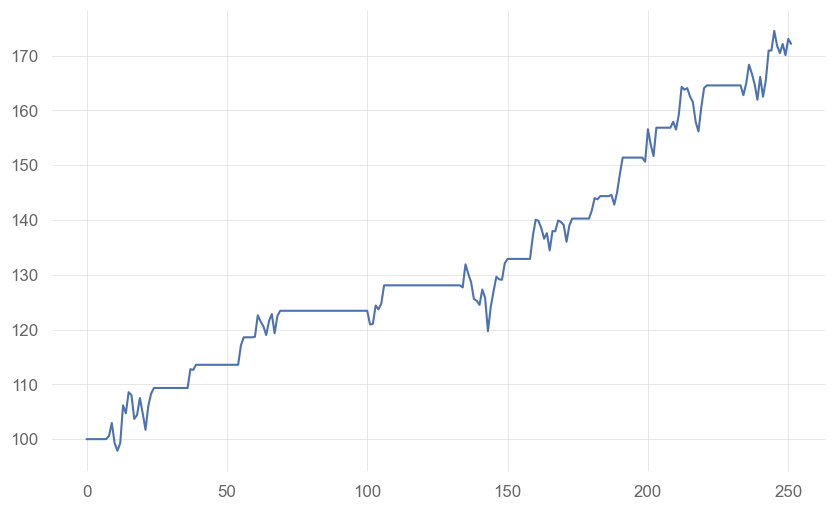

In [87]:
plt.plot(backtest(4))

Your functions should return and print a % returns list on your bankroll.

## Related Calculations
Do NOT give each other your functions - I will know because there are only 6 of you. You can discuss algorithms generally though.

Given returns list write a function to calculate:

In [96]:
returns = [0.014444938936158573, -0.0004930523210489213, -0.0006385339041039251, 0.013818208997700317, 0.026301200783317318, -0.001779877071875669, 0.01650337790942481, 0.03106180946851108, -0.0003387203838370106, -0.011860191575032122, -0.019540095812088168, -0.007232834773399626, 0.013433256949880935, 0.012810476120409343, -0.02847412570245763, 0.005393706012797481, 0.003339442866030822, 0.006895841848775082, 0.004969010858380491, -0.005131364596574809, 0.0069206799544494135, -0.01072313566569038, 0.01399250516206918, -0.020981481594640687, 0.030273352938138015, -0.025682416094134228, 0.0015733189011608625, -0.014464971613839502, 0.007399119635268282, 0.006391175724026929, 0.0023468504940836804, -0.028579794766157955, 0.00949982707123365, 0.015077191099775001, 0.043098120522979545, -0.03926976963780177, -0.00020864821893394484, 0.0024803437495366882, -0.030016827662751953, 0.00906605376616409, 0.016589912103690964, -0.004700933078097385, 0.01429056337979602, 0.023976618221569657, -0.01576595290056508, 0.001282008667934815, -0.03585042665373229, 0.03331568143103919, -0.012118110564048433, 0.014347596280877223, -0.003469885482831628, 0.002209905443680415, 0.042890313769773085, -0.013498518160022068, 0.007287740315120499, -0.002710175765789769, 0.0048873882498276, 0.002357926138970208, 0.005086631213361703, 0.018889961912629732, 0.020598250057572605, 0.005783435288583552, 0.03326851311673528, 0.013669993793929448, 0.0004736173580426322, -0.0015111528489299428, 0.03285601430644612, 0.03211211937940326, 0.04018764709732221, 0.014241481810516982, 0.0001273232467931761, 0.00540898661664189, 0.001644756054125939, 0.037986078147684024, 0.012614148194796943, -0.05498015213044833, 0.03323603690534521, 0.015959330839380358, 0.0019303547458361149, -0.00515194113056794, -0.017029767873395343, -0.009579552499771231, -0.0033719777543037574, 0.025857007272279034, 0.019831157283219256, 0.0027855971029958934, 0.00859490940106122, 0.00254848448008129, -0.010002913048581231, 0.03615255189057173, 0.004997381471530173, -0.003964503446044692, 0.0158436001315348, -0.016927525382197682, -0.038701535269150156, -0.0060269947885461805, 0.006766751005305049, 0.02990651438767488, 0.009434017987916618, 0.019553330327579645, -0.009092892219304746, 0.02163204273104874, -0.018691529442333113, 0.023368951875268343, 0.039020231623120426, 0.0047137592575821185, -0.0053208607415758695, -0.009789105308282966, 0.01000646841097234, -0.02481936319310512, -0.011693017678296416, -0.015263823021703765, 0.005764128510536403, -0.0007046351344448653, 0.005610742830414798, 0.024447205808376518, 0.011820961964125076, 0.0025950596395427706, 0.004136166606279353, 0.027064743338472787, 0.0374413378061835, -2.9872078177775683e-05, 0.0138631130391218, 0.005128886686586832, -0.010803867770632502, 0.004565801856559448, -0.000468041564455398, 0.0017532425654561137, -0.008536578682413492, 0.020817422228369152, -0.003542134499579807, -0.02293113419894667, -0.03529504909129597, 0.011042188146167833, -0.0013723082508056762, 0.035493952489747405, -0.051231534394471805, 0.010344651813267559, -0.012296667889781088, 0.0003699754828616333, -0.018091152881923096, -0.014675165130041601, -0.0025842212531457937, -0.03542087906878385, 0.011734993547838163, 0.00992977086030859, 0.001296113847969418, -0.03811106734930528, -0.018634757788419942, -0.018505866255001627, 0.012577921762661029, -0.010976664926826425, 0.006667715934787111, 0.008171633023781117, -0.04072628993006149, 0.005067382376424569, -0.011238577333764299, 0.009495941002919766, 0.0031548782000851375, 0.009468570754128793, 0.0028753763539774123, -0.0316466817774397, 0.002660717182280415, 0.014130390590554627, -0.0034308121620604086, -0.02978371656088768, -0.018725518961151946, 0.01354522651020001, -0.029629120842732046, 0.01691727348995557, 0.009682993773131053, -0.013500190747418126, 0.012781283455874735, -0.00890182504166158, -0.0022769945269973217, 0.009556213036113807, -0.002794034886346446, 0.029319664112685807, 0.02025744443182561, -0.0004523999311378639, 0.01643505071692728, 0.002107827035200472, -0.03074175652372961, 0.01606134067821033, 0.061197118118505554, -0.0010281044017078802, -0.020619133962397, 0.0175440980742627, -0.012055955199963315, -0.004302617100492898, 0.013015731722169091, 0.014236048427753318, 0.03999469005139292, 0.0016930639372143865, -0.007948846670334795, 0.020821376103926703, -3.695294231955077e-05, 0.030578890769963916, -0.05676522816302411, 0.008523034832859117, -0.028791173700336015, -0.004095598982130474, 0.006169154924111058, 0.01057741249819923, 0.015464145161167545, -0.01278139833379296, 0.012446755649607903, 0.009282424627646252, 0.006389198654748927, 0.00924302468286484, 0.0021498800194315413, -0.015601782834142161, -0.0030970440268565935, -0.0005875757465728551, -0.007183255825138655, -0.011074626366412557, -0.012379780005744311, 0.0024190247362442362, 0.006456441468151853, 0.022310267850703752, -0.05317933011274769, 0.005712678153792701, 0.007452175244951341, -0.010972672085732844, -0.0338341832976642, 0.009005777502447118, -0.0041903194664729, -0.007491408756839412, 0.007728482282725759, -6.0191138659467826e-05, -0.0016759512106886399, -0.014903639327498915, 0.008670717124620923, -0.017639964995187926, 0.009509378941310601, 0.05184986615627394, -0.03151446696220217, 0.0005575893749074677, -0.013333019874109486, 0.007465834169575692, -0.02709877322754594, -0.0037837915709873016, -0.011463000215329826, -0.006479876760540185, -0.018505187105223045, -0.014531327371043306, 0.0022339186091288057, 0.06256085367065824, -0.019131725693546438, 0.02739863007867626, -0.004954753218748621, -0.003296282276762896]

Cumulative returns assuming returns compound (you’re betting entire bankroll every trade)

In [89]:
def cum_returns(returns):
    cum = 1
    for r in returns:
        cum *= 1 + r
    return cum - 1
print(cum_returns(returns))

0.458154193457206


Daily volatility

In [90]:
def daily_vol(returns):
    cum_vol = 0
    mean = np.mean(returns)
    for r in returns:
        cum_vol += (r - mean) ** 2
    return np.sqrt(cum_vol / (len(returns) - 1))
print(daily_vol(returns))

0.019364719095058346


Monthly and annual volatility

In [91]:
def monthly_vol(returns):
    return daily_vol(returns) * np.sqrt(21)

def annual_vol(returns):
    return daily_vol(returns) * np.sqrt(252)

print(monthly_vol(returns))
print(annual_vol(returns))

0.08874029106466162
0.3074053856048888


Sharpe with monthly volatility (rfr = 0.02)

In [92]:
def Sharpe(returns):
    excess_returns = [r - 0.02 / 252 for r in returns]
    volatility = np.std(excess_returns, ddof=1)
    return (np.mean(excess_returns) / volatility) * np.sqrt(252)
print(Sharpe(returns))

1.3159462989648352


Kurtosis of returns

In [93]:
def kurt(returns):
    length = len(returns)
    numerator = 0
    denominator = 0
    mean = np.mean(returns)
    for r in returns:
        numerator += (r - mean) ** 4
        denominator += (r - mean) ** 2
    numerator /= length
    denominator = (denominator / length) ** 2
    return numerator / denominator
print(kurt(returns))

3.8538139713638127


Max drawdown in % terms - considering the changes over time in your bankroll, what is the greatest % decrease in the value of the bankroll over and timespan?

In [99]:
def max_drawdown(returns):
    bankroll = []
    value = 100
    for r in returns:
        value *= 1 + r
        bankroll.append(value)
    peak = max(bankroll)
    trough = min(bankroll)
    return (trough - peak) / peak

max_drawdown(returns)


-0.44062264602535833

#### Bonus
How do you think I generated the data for pairs trade, ETF arbitrage, and the returns list? They are similar but each has slight adjustments. Look for patterns in the data. 
<br> Answer here: